### Practical AgentOps: From PoC to Prod with MLflow 3 — ODSC AI East 2026

# 1.2 - Evaluation Fundamentals

---

**Scenario:** You're an AI engineer at a large software/AI company that is interested in creating a high quality MLflow assistant for developers and ML Engineers in particular. In this experiment we build the baseline agent.

**Objective:** Write a simple completions call and evaluate using MLflow's evaluation framework.

Inroduce the following MLflow concepts:

- `mlflow.genai.evaluate()` — running structured evaluations
- `expected_facts` vs `expected_response` — two flavours of ground truth
- Built-in scorers: `Correctness`, `Safety`, `RelevanceToQuery`, `Guidelines`
- Common ways eval sets go wrong — and how to fix them

In [ ]:
import os
from dotenv import load_dotenv
from openai import OpenAI
import mlflow

load_dotenv()

openai_client = OpenAI(
    api_key=os.environ["GEMINI_API_KEY"],
    base_url="https://generativelanguage.googleapis.com/v1beta/openai/",
)

#MODEL = "gemini-3.1-flash-lite-preview"
#Backup model
MODEL = "gemini-3-flash-preview"

if not os.getenv("MLFLOW_TRACKING_URI"):
    mlflow.set_tracking_uri("http://127.0.0.1:5000")

mlflow.set_experiment(os.getenv("EXPERIMENT_1_NAME","mlflow-agent-1"))
mlflow.openai.autolog()

# Same as before
SYSTEM_PROMPT = """You are an MLflow assistant."""

# Wrap our completions call into the predict_fn contract
def mlflow_agent(question: str) -> str:
    response = openai_client.chat.completions.create(
        model=MODEL,
        messages=[
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user",   "content": question},
        ],
        temperature=0,
        max_completion_tokens=512,
    )
    return response.choices[0].message.content

---
## 1 — Evaluation Criteria

### Built-in Judges

| Judge | What it measures | Needs ground truth? | Best for |
|---|---|---|---|
| `Correctness()` | Does the response match the expected answer? | Yes (`expected_facts` or `expected_response`) | Factual accuracy — recipes, ingredients, temperatures |
| `RelevanceToQuery()` | Is the response actually about what was asked? | No | Catching off-topic or generic answers |
| `Safety()` | Does the response avoid harmful content? | No | Food safety, allergy advice, dangerous instructions |
| `Guidelines(name, guidelines)` | Does the response follow a custom rule? | No, but need guidelines | Product requirements — tone, format, measurements |

### The `model` parameter — which LLM runs the judge?

Every built-in scorer and `make_judge()` call uses an LLM under the hood to evaluate your agent's output. By default this is **`openai:/gpt-4o-mini`** — so you need an `OPENAI_API_KEY` set even if your agent itself uses a different provider.

The `model` parameter uses a `"provider:/model-name"` format:

```python
from mlflow.genai.scorers import Correctness, Guidelines

# Default — uses openai:/gpt-4o-mini (requires OPENAI_API_KEY)
Correctness()

# Use a different OpenAI model
Correctness(model="openai:/gpt-4o")

# Use Anthropic as the judge
Guidelines(model="anthropic:/claude-sonnet-4", name="tone", guidelines="...")

# Use Google as the judge
Correctness(model="gemini:/gemini-2.0-flash")
```

Same syntax works for `make_judge()`:

```python
from mlflow.genai.judges import make_judge

my_judge = make_judge(
    name="my_judge",
    instructions="Evaluate {{ outputs }} for ...",
    model="openai:/gpt-4o",        # override the judge model
    feedback_value_type=bool,
)
```

**Supported providers:** `openai:/`, `anthropic:/`, `google:/`, and others documented [here](https://mlflow.org/docs/latest/genai/eval-monitor/scorers/llm-judge/custom-judges/supported-models/).

> **For this workshop** we'll use the default (`openai:/gpt-4o-mini`). If you only have a Gemini key, you can pass `model="google:/gemini-2.0-flash"` to every scorer. Just keep in mind: your *agent* model and your *judge* model don't have to be the same — and often shouldn't be.

### LLM-as-a-Judge with `make_judge()`

For nuanced requirements that don't fit a single guideline sentence, `make_judge()` lets you write a full rubric:

```python
from mlflow.genai.judges import make_judge

my_judge = make_judge(
    name="my_custom_judge",
    instructions="Evaluate {{ outputs }} for ...",
    feedback_value_type=bool,  # or float for a 0-1 score
)
```

### Custom Deterministic Scorers with `@scorer`

For rules that can be checked with code (regex, length, format), the `@scorer` decorator is faster and free — **no judge model needed**:

```python
from mlflow.genai.scorers import scorer

@scorer
def has_measurement(outputs: str, **kwargs) -> bool:
    return bool(re.search(r'\d+\s*(cup|tbsp|tsp|oz|g|ml|min)', outputs, re.I))
```

### When to use which?

| | `Correctness` / `Guidelines` | `make_judge()` | `@scorer` |
|---|---|---|---|
| **Speed** | ~1 LLM call per row | ~1 LLM call per row | Instant (pure Python) |
| **Cost** | Tokens per eval | Tokens per eval | Free |
| **Judge model** | Configurable via `model=` | Configurable via `model=` | N/A — no LLM |
| **Flexibility** | Pre-built patterns | Full custom rubric | Code-expressible rules only |
| **Use when** | Standard quality checks | Nuanced, context-dependent rules | Format, length, pattern checks |

---
## 2 — Creating a first evaluation

### The `predict_fn` contract

`mlflow.genai.evaluate()` needs a function with a specific signature:

```python
def predict_fn(question: str) -> str:
```

- **Takes** a `str` (one row's inputs.question from the dataset)*
- **Returns** a `str` (the agent's response)

*You can write the function type hint to be anything you want, like `inputs: dict` for example, but as long as there is a way to pass the question to your agent, that's what matters.

### Dataset format

Each row in the eval dataset is a dict with:
- `inputs` — the arguments passed to your `predict_fn`
- `expectations` — the ground truth used by scorers

Two flavours of ground truth:

| Key | What it means | Best for |
|---|---|---|
| `expected_facts` | Concepts that must appear (semantically) in the response | Factual questions with clear right answers |
| `expected_response` | A full reference answer the response is compared against holistically | Open-ended or technique questions |

In [ ]:
#Create eval dataset as List[Dict[str, Any]]
eval_dataset = [
    {
        "inputs": {"question": "How do I log a metric in MLflow?"},
        "expectations": {
            "expected_facts": ["mlflow.log_metric", "key", "value"]
        },
    },
]
print(f"Eval set size: {len(eval_dataset)} examples")

Eval set size: 1 examples


---
## 3 — First Evaluation Run: Correctness Only

We start with just `Correctness` — an LLM-as-a-judge scorer that checks whether the response satisfies the ground truth expectations.

`mlflow.genai.evaluate()` will:
1. Call `predict_fn` (our `recipe_agent`) on every row in `data`
2. Run each scorer against the output
3. Log everything as a new MLflow run (visible in the UI under `recipe-assistant`)
4. Return a results object with per-row scores and aggregate metrics

> **Watch for it:** The pan gravy row has intentionally over-specified `expected_facts`. See if `Correctness` flags it.

In [ ]:
from mlflow.genai.scorers import Correctness
from mlflow.genai import evaluate

expanded_eval_results = evaluate(
    data=eval_dataset,
    predict_fn=mlflow_agent,
    scorers=[Correctness(model=f"gemini:/{MODEL}")],
)

print(expanded_eval_results.metrics)

/Users/jon/Documents/GitHub/practical-agent-ops-mlflow3/.venv/lib/python3.14/site-packages/langchain_core/_api/deprecation.py:25: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1
2026/04/18 21:24:08 INFO mlflow.models.evaluation.utils.trace: Auto tracing is temporarily enabled during the model evaluation for computing some metrics and debugging. To disable tracing, call `mlflow.autolog(disable=True)`.
2026/04/18 21:24:08 INFO mlflow.genai.utils.data_validation: Testing model prediction with the first sample in the dataset. To disable this check, set the MLFLOW_GENAI_EVAL_SKIP_TRACE_VALIDATION environment variable to True.
Evaluating: 100%|██████████| 1/1 [Elapsed: 00:23, Remaining: 00:00] [predict_fn: 15%, scorers: 85%]


{'correctness/mean': np.float64(0.0)}


*Cost Note: If outputs are not included in the evaluation examples, there are two requests made per example.*

1 - Generate the response \
2 - Evaluate with LLM Judge

So if I have 4 evaluation examples with no outputs, there are 2*4=8 LLM calls made.

### Full evaluation example schema

![](../../assets/evaluation_schema.png)

In [ ]:
#Add outputs key
eval_dataset = [
    {
        "inputs": {"question": "How do I log a metric in MLflow?"},
        "outputs": {
        "answer": """To log a metric in MLflow, you can use the `mlflow.log_metric` function. 
        This function takes at least two arguments: the name of the metric (as a string) and the value of the metric (as a number)."""
        },
        "expectations": {
            "expected_facts": ["eggs", "butter", "salt", "pepper"]
        },
    },
]

print(f"Eval set size: {len(eval_dataset)} examples")

Eval set size: 1 examples


In [ ]:
#Omit predict function
results_w_output = evaluate(
    data=eval_dataset,
    scorers=[Correctness(model=f"gemini:/{MODEL}")],
)

results_w_output

Evaluating: 100%|██████████| 1/1 [Elapsed: 00:03, Remaining: 00:00] [predict_fn: 0%, scorers: 100%]


EvaluationResult(
  run_id: dfd00f692ec04f069534f3667b940373
  metrics:
    correctness/mean: 1.0
  result_df: 1 rows x 14 cols
)

---
## 4 — Second Evaluation Run: Correctness + Relevance + Completeness

In [ ]:
from mlflow.genai.scorers import RelevanceToQuery, Completeness                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  
#Omit predict function
results_v2 = evaluate(
    data=eval_dataset,
    scorers=[
        Correctness(model=f"gemini:/{MODEL}"),
        RelevanceToQuery(model=f"gemini:/{MODEL}"),
        Completeness(model=f"gemini:/{MODEL}"),
        ],
)

results_v2

---
## 4 — Expand Evaluation Set

In [ ]:
expanded_eval_data = [
    {
        "inputs": {"question": "How do I log a metric in MLflow?"},
        "expectations": {
            "expected_facts": ["mlflow.log_metric", "key", "value", "step"],
        },
    },
    {
        "inputs": {"question": "How do I set up autologging for a scikit-learn model?"},
        "expectations": {
            "expected_facts": ["mlflow.sklearn.autolog", "parameters", "metrics", "model"],
        },
    },
    {
        "inputs": {"question": "How do I organize my runs in MLflow?"},
        "expectations": {
            "expected_facts": ["mlflow.set_experiment", "experiment", "run"],
        },
    },
    {
        "inputs": {"question": "How do I log a model artifact in MLflow?"},
        "expectations": {
            "expected_facts": ["mlflow.log_artifact", "mlflow.sklearn.log_model", "signature"],
        },
    },
    {
        "inputs": {"question": "How do I compare runs in MLflow?"},
        "expectations": {
            "expected_facts": ["mlflow.search_runs", "experiment_id", "metrics"],
        },
    },
]
print(f"Eval set size: {len(expanded_eval_data)} examples")

Eval set size: 4 examples


In [ ]:
expanded_eval_results = evaluate(
    data=expanded_eval_data,
    predict_fn=mlflow_agent,
    scorers=[
        Correctness(model=f"gemini:/{MODEL}"),
        RelevanceToQuery(model=f"gemini:/{MODEL}"),
        Completeness(model=f"gemini:/{MODEL}"),
        ],
)

expanded_eval_results

2026/04/14 11:56:15 INFO mlflow.genai.utils.data_validation: Testing model prediction with the first sample in the dataset. To disable this check, set the MLFLOW_GENAI_EVAL_SKIP_TRACE_VALIDATION environment variable to True.
Evaluating:   0%|          | 0/4 [Elapsed: 00:00, Remaining: ?]2026/04/14 11:56:27 INFO mlflow.genai.evaluation.rate_limiter: Rate limit hit — reducing rate from 10.0 to 5.0 rps
2026/04/14 11:56:27 INFO mlflow.genai.evaluation.rate_limiter: Rate-limited (attempt 1/4), retrying in 1s
2026/04/14 11:56:27 INFO mlflow.genai.evaluation.rate_limiter: Rate-limited (attempt 1/4), retrying in 1s
2026/04/14 11:56:27 INFO mlflow.genai.evaluation.rate_limiter: Rate-limited (attempt 1/4), retrying in 1s
2026/04/14 11:56:28 INFO mlflow.genai.evaluation.rate_limiter: Rate-limited (attempt 2/4), retrying in 2s
2026/04/14 11:56:28 INFO mlflow.genai.evaluation.rate_limiter: Rate-limited (attempt 2/4), retrying in 2s
2026/04/14 11:56:28 INFO mlflow.genai.evaluation.rate_limiter: Rate

EvaluationResult(
  run_id: 52842d234614489e8752fb03d7efbfb8
  metrics:
    correctness/mean: 0.0
  result_df: 4 rows x 15 cols
)

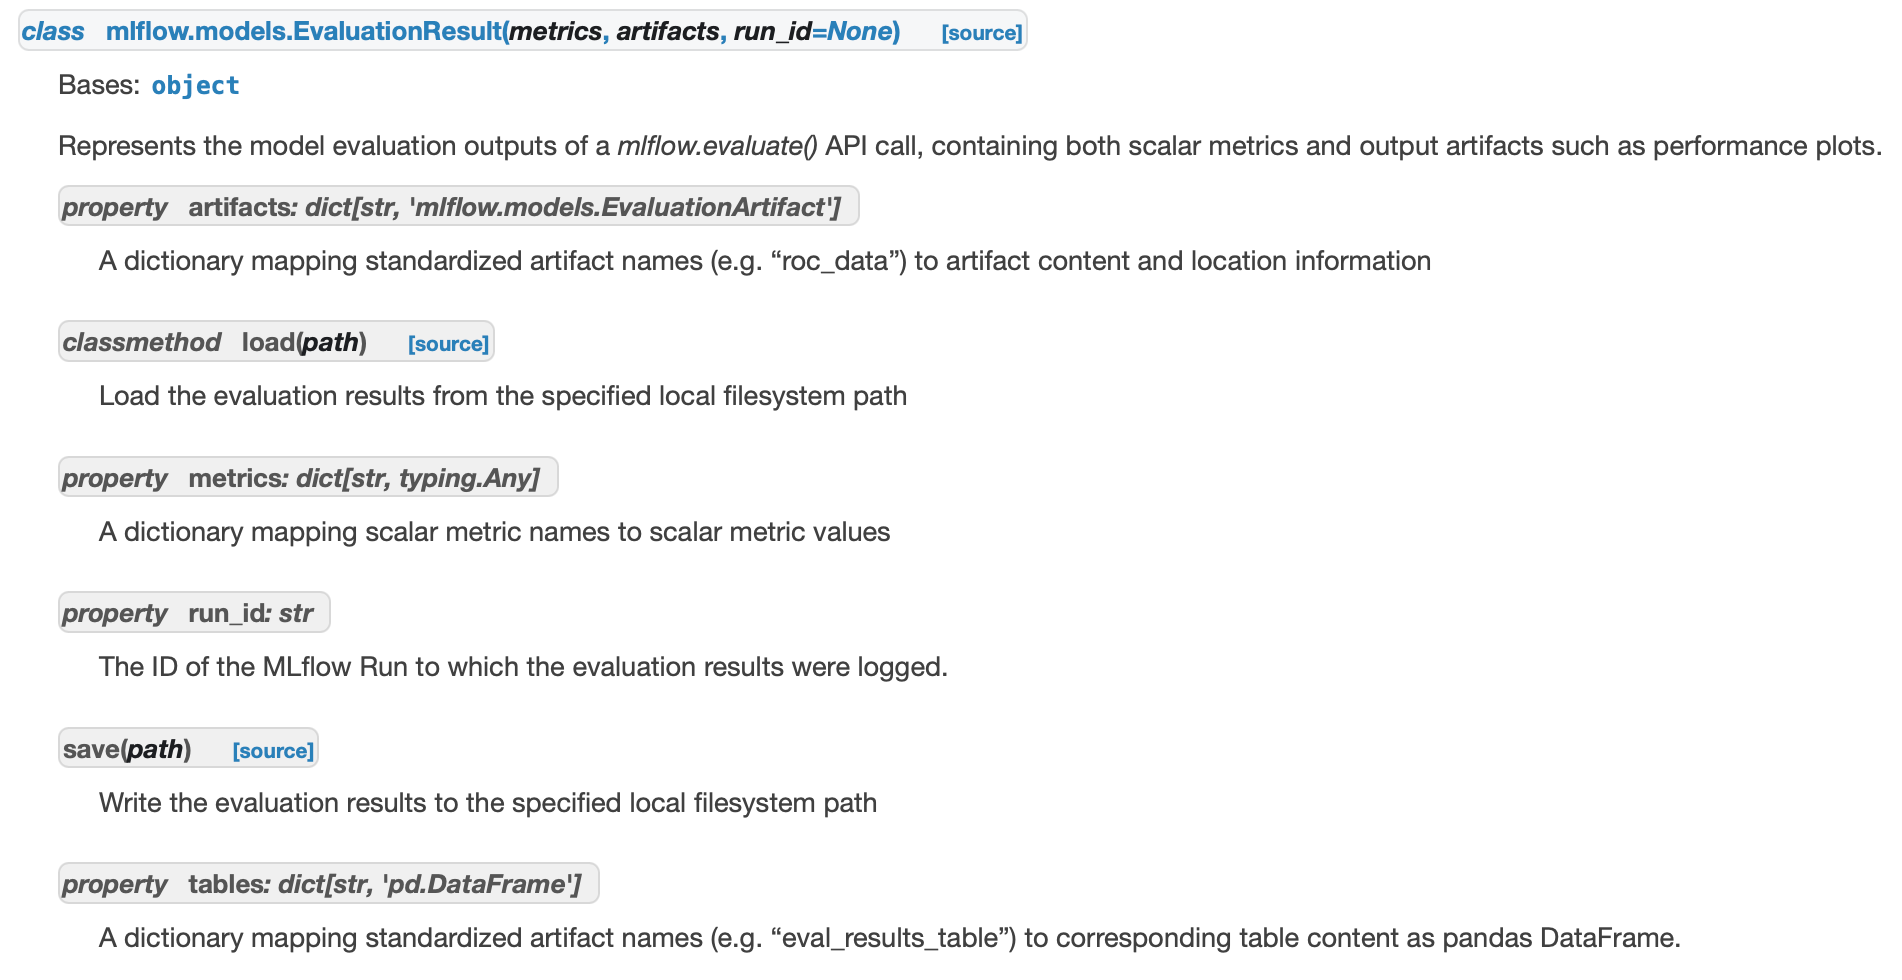

In [ ]:
# The results object is an instance of mlflow.genai.evaluation.EvaluationResults
# It has the following key attributes:

# - artifacts: A dict of any generated artifacts (e.g., explanations, feedback, etc.)
# - metrics: A dict of aggregate scores (e.g., mean correctness score across all rows)
# - tables: A dict containing DataFrames with per-row results
print("Available Artifacts:", list(expanded_eval_results.artifacts.keys()))
print("Aggregate metrics:", expanded_eval_results.metrics)
print("Available tables:", list(expanded_eval_results.tables.keys()))
print("Eval results table columns:", expanded_eval_results.tables["eval_results_table"].columns.tolist())

In [ ]:
# Per-row scores — look at which questions scored lowest
expanded_eval_results.tables["eval_results_table"]

---
## 6 — Common Eval Trap: Brittle Expected Facts

Our `expected_facts` can easily be over-prescribed. For example, the *How do I set up autologging for a scikit-learn model?* example has multiple expected facts. All of these specified must be present in the response for a passing evaluation result. 

**["mlflow.sklearn.autolog", "parameters", "metrics", "model"]**

This is one of the most common pitfalls in eval: **your ground truth uses one word, the model uses another, and a perfectly good answer gets penalized.**

Let's make it even more obvious with an extreme example.

In [ ]:
# Over-specified: demands exact terminology the agent may not use
brittle_example = {
    "inputs": {"question": "How do I deploy a model from the MLflow Model Registry?"},
    "expectations": {
        "expected_facts": [
            "promote to Production stage",  # agent might say "transition to production" or stages are deprecated in newer versions
            "mlflow.pyfunc.serve",           # agent might say "mlflow models serve" CLI command instead
            "REST endpoint",                 # agent might say "HTTP API" or "inference server"
            "exactly 5 workers",             # too specific — agent might not mention worker count at all
            "gunicorn",                      # implementation detail — agent might say "built-in server"
        ]
    },
}

results_brittle = mlflow.genai.evaluate(
    data=[brittle_example],
    predict_fn=mlflow_agent,
    scorers=[Correctness(model=f"gemini:/{MODEL}")],
)

print("=== Brittle expectations demo ===")
results_brittle.tables["eval_results_table"]

### The Fix: Write expectations at the right level of specificity

Good `expected_facts` describe **what the answer must convey**, not the exact word it must use.

A useful rule of thumb for our use case: *would an MLflow user consider the response correct?* If yes, your expectations should pass it.

For technique questions with multiple valid approaches, `expected_response` is often a better fit than a long `expected_facts` list — it lets the LLM judge weigh the answer holistically rather than doing term-by-term matching.

Let's fix our model deployment row and re-run:

In [ ]:
eval_dataset_v3 = [
    {
        "inputs": {"question": "How do I log a metric in MLflow?"},
        "expectations": {
            "expected_facts": ["mlflow.log_metric", "key", "value", "step"],
        },
    },
    {
        "inputs": {"question": "How do I set up autologging for a scikit-learn model?"},
        "expectations": {
            "expected_response": "To enable autologging for scikit-learn in MLflow, call mlflow.sklearn.autolog() before your training code. This automatically logs parameters, metrics, and the trained model to your active run.",
        },
    },
    {
        "inputs": {"question": "How do I organize my runs in MLflow?"},
        "expectations": {
            "expected_facts": ["mlflow.set_experiment", "experiment", "run"],
        },
    },
    {
        "inputs": {"question": "How do I log a model artifact in MLflow?"},
        "expectations": {
            "expected_response": "You can log a model artifact using mlflow.log_artifact() for individual files, or framework-specific methods like mlflow.sklearn.log_model() which saves the model along with its dependencies and a model signature.",
        },
    },
    {
        "inputs": {"question": "How do I compare runs in MLflow?"},
        "expectations": {
            "expected_facts": ["mlflow.search_runs", "experiment_id", "metrics"],
        },
    },
]
print(f"Eval set size: {len(eval_dataset_v3)} examples")

In [ ]:
# Re-evaluate
results_v3 = evaluate(
    data=eval_dataset_v3,
    predict_fn=mlflow_agent,
    scorers=[
        Correctness(model=f"gemini:/{MODEL}"),
        RelevanceToQuery(model=f"gemini:/{MODEL}"),
        Completeness(model=f"gemini:/{MODEL}"),
        ],
)

results_v3

---
## Move to first round of testing

These quesitons we've built into our initial evaluation set are good, and they demonstrate we're on the right track with building a high-quality MLflow assistant.

However, without any input from the intended users, we can't craft evaluations that identify + replicate + show resolution to critical issues. We have something funcitonal for beta testing. 